# EVASPA Evaporative Fraction processing

In [1]:
from __future__ import annotations

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import ListedColormap

In [4]:
from evaspa.ef import EFModel, check_variability, initialize, run
from evaspa.filter import determine_valid_pixels
from evaspa.io import read_data_from_file

In [5]:
if os.environ["EVASPA_TEST_DATA_PATH"] is None:
    msg = "Variable EVASPA_TEST_DATA_PATH must be set"
    raise ValueError(msg)

### Get test data 

In [6]:
file_path = os.path.join(
    os.environ["EVASPA_TEST_DATA_PATH"], "Landsat_20230327_28PCA.tif"
)

In [7]:
data = read_data_from_file(file_path)
data

<xarray.Dataset> Size: 188MB
Dimensions:  (y: 1832, x: 1832)
Coordinates:
  * x        (x) float64 15kB 3e+05 3.001e+05 3.002e+05 ... 4.098e+05 4.099e+05
  * y        (y) float64 15kB 1.6e+06 1.6e+06 1.6e+06 ... 1.49e+06 1.49e+06
Data variables: (12/14)
    red      (y, x) float32 13MB 0.2229 0.2041 0.1904 0.2109 ... nan nan nan nan
    blue     (y, x) float32 13MB 0.1012 0.09499 0.08831 0.09488 ... nan nan nan
    green    (y, x) float32 13MB 0.1601 0.1486 0.1398 0.152 ... nan nan nan nan
    nir      (y, x) float32 13MB 0.3612 0.3415 0.3288 0.3406 ... nan nan nan nan
    lst      (y, x) float32 13MB 323.2 323.6 323.7 323.6 ... nan nan nan nan
    emis     (y, x) float32 13MB 0.96 0.9572 0.9577 0.9591 ... nan nan nan nan
    ...       ...
    lai      (y, x) float32 13MB 0.2078 0.2222 0.237 0.2063 ... nan nan nan nan
    rsd      (y, x) float32 13MB 806.6 806.6 806.6 806.7 ... 819.9 819.9 819.9
    rld      (y, x) float32 13MB 348.8 348.9 348.9 348.9 ... 358.4 358.4 358.4
    qa       (y, x) float32 13MB 1.0 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    cloud    (y, x) float32 13MB 0.0 0.0 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0 1.0
    water    (y, x) float32 13MB 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    crs:        EPSG:32628
    transform:  | 60.00, 0.00, 300000.00|\n| 0.00,-60.00, 1600140.00|\n| 0.00...

In [ ]:
coords = dict(data.sizes, band=3)
coords

{'y': 1832, 'x': 1832, 'band': 3}

In [9]:
def plot_rgb(data: xr.Dataset, bands: list[str] | None = None):
    if bands is None:
        bands = ["red", "green", "blue"]
    rgb = xr.DataArray(
        np.dstack(
            (data[bands[0]].data, data[bands[1]].data, data[bands[2]].data)
        ),
        data.coords.assign(band=["r", "g", "b"]),
        dict(data.sizes, band=3),
    )
    rgb.plot.imshow(  # type: ignore
        rgb="band",
        vmin=rgb.quantile(0.01),
        vmax=rgb.quantile(0.99),
    )
    plt.title("RGB")


def plot_band(data: xr.Dataset, band: str):
    data[band].plot.imshow(  # type: ignore
        vmin=data[band].quantile(0.01),
        vmax=data[band].quantile(0.99),
    )


def plot_mask(data: xr.Dataset, mask: str, invert=False):
    cmap = [(0.0, 0.0, 0.0, 0.0)]
    if len(np.unique(data[mask].data)) > 1:
        cmap = [(1.0, 0.0, 0.0, 1.0), (0.0, 0.0, 0.0, 0.0)]
    if invert:
        cmap = cmap[::-1]
    valid_cmap = ListedColormap(cmap)
    data[mask].plot(cmap=valid_cmap, add_colorbar=False)


def plot(
    data: xr.Dataset,
    var_name: str | None = None,
    model: EFModel | None = None,
    save: bool = False,
):
    """
    Plot
    """
    # dimensions
    # gridspec inside gridspec
    fig = plt.figure(constrained_layout=True, figsize=(4, 3))

    ax = plt.gca()

    if var_name is None and model is None:
        msg = "Provide either var_name or model"
        raise ValueError(msg)
    lst = data["lst"].data

    if var_name is not None:
        var = data[var_name].data
        # plot all points
        ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)

    # plot edges
    elif model is not None:
        var_name = model.var
        var = data[model.var].data
        # plot all points
        ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)
        # edges coordinates
        var_max = np.round(np.ceil(np.nanmax(var) * 10) / 10, decimals=1)
        var_min = np.round(np.floor(np.nanmin(var) * 10) / 10, decimals=1)

        var_arr = np.linspace(var_min, var_max, num=20)
        tw_arr = model.twet(var_arr)
        td_arr = model.tdry(var_arr)

        ax.plot(
            var_arr,
            td_arr,
            color="tab:red",
            linewidth=3,
            label="dry edge",
            zorder=1,
        )
        ax.plot(
            var_arr,
            tw_arr,
            color="tab:blue",
            linewidth=3,
            label="wet edge",
            zorder=1,
        )

    # Labels
    ax.set_xlabel(var_name)
    ax.set_ylabel("Land Surface Temperature K")

    # title
    ax.set_title("Evaporative fraction method", fontsize=12)

    # savefig
    if save:
        destfile = "ef.png"
        fig.savefig(destfile)

    plt.show()

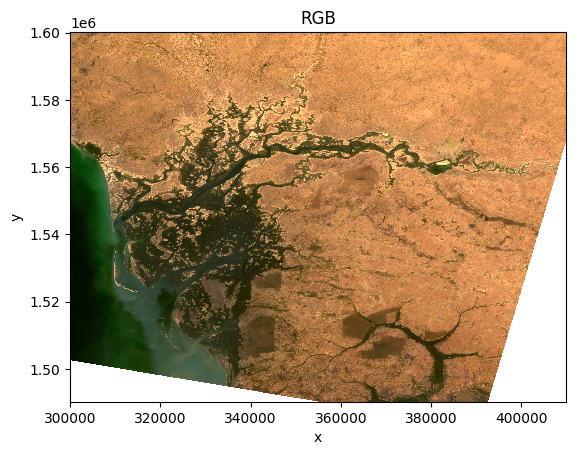

In [10]:
plot_rgb(data)

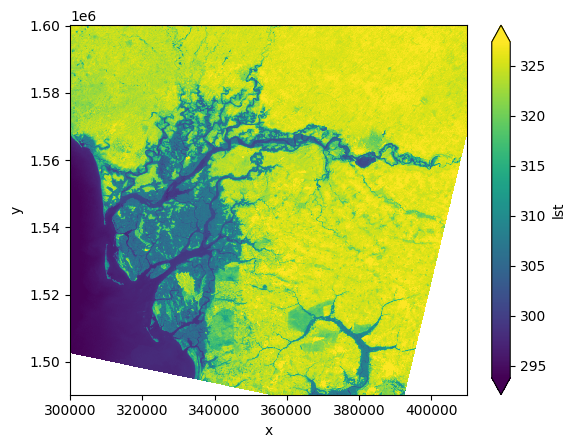

In [ ]:
plot_band(data, "lst")

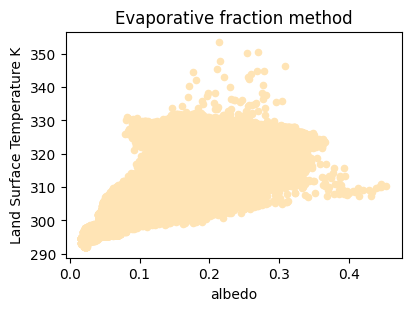

In [ ]:
plot(data, "albedo")

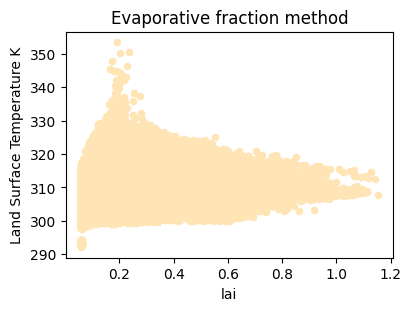

In [13]:
plot(data, "lai")

### Configuration

In [14]:
config = {
    "models": [
        {
            "name": "model1",
            "dry_edge": {
                "type": "LinearEdge",
                "config": {
                    "interval_type": "size",
                    "interval_nb": 20,
                    "percentile": [98, 100],
                    "selection": "median",
                },
            },
            "wet_edge": {
                "type": "LinearEdge",
                "config": {
                    "interval_type": "size",
                    "interval_nb": 20,
                    "percentile": [0, 2],
                    "selection": "median",
                },
            },
            "var": "albedo",
        },
        {
            "name": "model2",
            "dry_edge": {
                "type": "LinearEdge",
                "config": {
                    "interval_type": "density",
                    "interval_nb": 20,
                    "percentile": [98, 100],
                    "selection": "median",
                },
            },
            "wet_edge": {
                "type": "FlatEdge",
                "config": {"selection": "min"},
            },
            "var": "lai",
        },
    ],
    "options": {
        "selection": False,
        "merging": "mean",
    },
}

In [15]:
pprint(config, sort_dicts=False)

{'models': [{'name': 'model1',
             'dry_edge': {'type': 'LinearEdge',
                          'config': {'interval_type': 'size',
                                     'interval_nb': 20,
                                     'percentile': [98, 100],
                                     'selection': 'median'}},
             'wet_edge': {'type': 'LinearEdge',
                          'config': {'interval_type': 'size',
                                     'interval_nb': 20,
                                     'percentile': [0, 2],
                                     'selection': 'median'}},
             'var': 'albedo'},
            {'name': 'model2',
             'dry_edge': {'type': 'LinearEdge',
                          'config': {'interval_type': 'density',
                                     'interval_nb': 20,
                                     'percentile': [98, 100],
                                     'selection': 'median'}},
             'wet_edge': {'type': 'Fl

### Process evaporative fraction

#### Filter

In [16]:
data["valid"] = determine_valid_pixels(data, cloud="cloud")

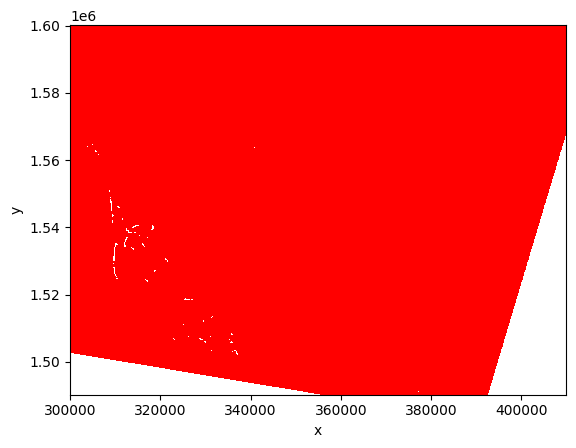

In [ ]:
plot_mask(data=data, mask="valid", invert=True)

#### Check variability

In [ ]:
check_variability(data["lst"], mask=data["valid"], threshold=0.1)

True

#### Compute EF

In [19]:
models, options = initialize(config)

In [ ]:
ef, ef_inst = run(models, data, mask=None, **options)

In [21]:
ef

<xarray.Dataset> Size: 54MB
Dimensions:  (x: 1832, y: 1832)
Coordinates:
  * x        (x) float64 15kB 3e+05 3.001e+05 3.002e+05 ... 4.098e+05 4.099e+05
  * y        (y) float64 15kB 1.6e+06 1.6e+06 1.6e+06 ... 1.49e+06 1.49e+06
Data variables:
    model1   (y, x) float64 27MB 0.0 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan nan
    model2   (y, x) float64 27MB 0.09625 0.08087 0.07252 0.08615 ... nan nan nan

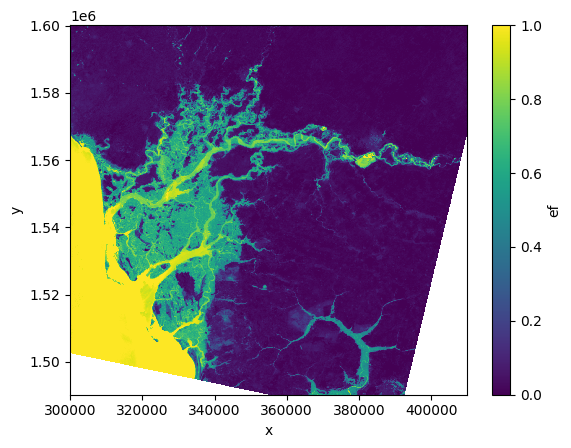

In [ ]:
plot_band(ef_inst, band="ef")

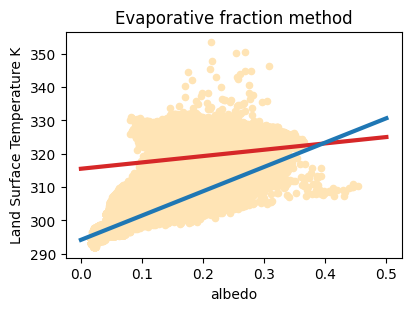

In [23]:
plot(data, model=EFModel.create(ef["model1"].attrs))

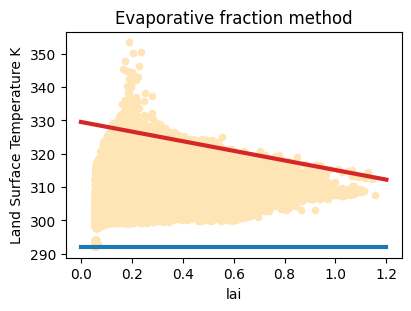

In [24]:
plot(data, model=EFModel.create(ef["model2"].attrs))